# modeles lineaires

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.datasets import make_regression

Text(0.5, 1.0, 'data')

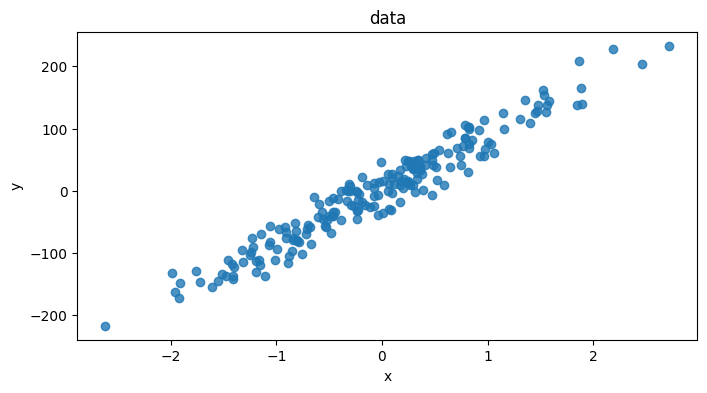

In [20]:
x, y = make_regression(n_samples=200, n_features=1, n_targets=1, noise=20, random_state=42)
plt.figure(figsize=(8, 4))
plt.scatter(x, y, alpha=0.8)
plt.xlabel("x")
plt.ylabel("y")
plt.title("data")

* SGDRegressor

In [27]:
model = SGDRegressor(loss="squared_error",
                     penalty="l2",
                     l1_ratio=0.15,
                     fit_intercept=True,
                     max_iter=1000,
                     tol=0.001,
                     learning_rate="invscaling",
                     eta0=0.01)
model.fit(x, y)
y_pred = model.predict(x)
model.score(x, y)

0.9413689235707278

Text(0.5, 1.0, 'SGDRegressor')

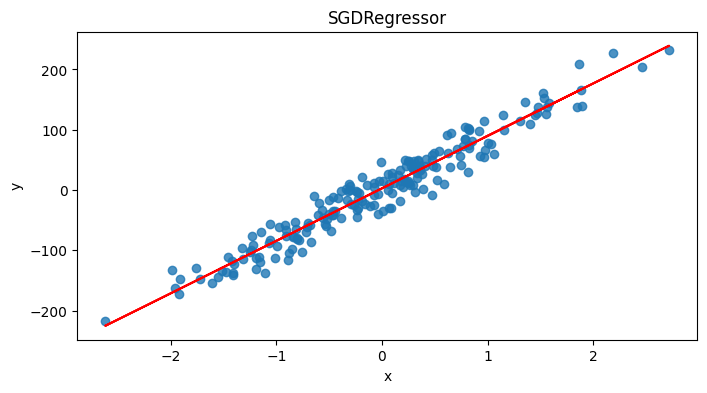

In [28]:
plt.figure(figsize=(8, 4))
plt.scatter(x, y, alpha=0.8)
plt.plot(x, y_pred, c="r")
plt.xlabel("x")
plt.ylabel("y")
plt.title("SGDRegressor")

* LinearRegressor

In [76]:
x, y = make_regression(n_samples=10000, n_features=2, noise=20, random_state=42)

In [54]:
y.shape

(10000,)

In [77]:
model = LinearRegression(fit_intercept=True,
                         copy_X=True,
                         tol=1e-6)
model.fit(x, y)
y_pred = model.predict(x)
model.score(x, y)

0.9607720972452705

In [81]:
x1_min, x1_max = x[:,0].min()-1, x[:,0].max()+1
x2_min, x2_max = x[:,1].min()-1, x[:,1].max()+1

xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, 0.2),
                       np.arange(x2_min, x2_max, 0.2))

grid = np.c_[xx1.ravel(), xx2.ravel()]
z = model.predict(grid)
Z = z.reshape(xx1.shape)
Z.shape

(47, 51)

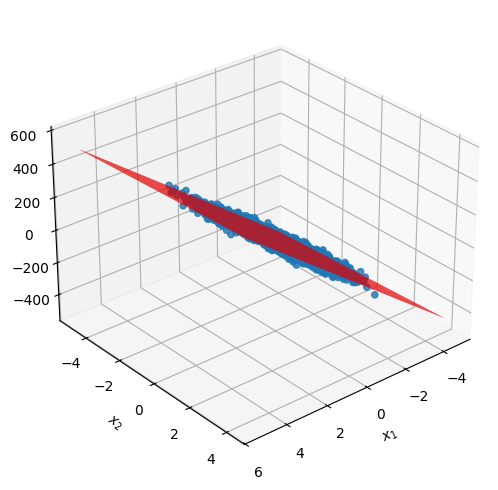

In [84]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection='3d')
ax.scatter(x[:,0], x[:,1], y, alpha=0.8)
ax.plot_surface(xx1, xx2, Z, color="r")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_zlabel("y")
# Change the viewpoint
ax.view_init(elev=29., azim=50.)

plt.show()

* SGDRegressor vs LinearRegressor - Comparaison des temps de calculs

In [ ]:
x, y = make_regression(n_samples=200, n_features=1, n_targets=1, noise=20, random_state=42)
plt.figure(figsize=(8, 4))
plt.scatter(x, y, alpha=0.8)
plt.xlabel("x")
plt.ylabel("y")
plt.title("data")

In [46]:
import time

def make_data(n_rows, n_cols):
    x, y = make_regression(n_samples=n_rows, n_features=n_cols, noise=20, random_state=42)
    return x, y

def train_model(model_name, x, y):
    model = model_name()
    start_time = time.time()
    model.fit(x, y)
    end_time = time.time() - start_time
    return model, end_time

def plot2cols(x, y, model1, model1_time, model2, model2_time):
    fig, ax = plt.subplots(1, 2, figsize=(12,4))
    ax[0].scatter(x, y)
    ax[0].plot(x, model1.predict(x), c="r")
    ax[0].set_title(f"{str(model1)} - score: {round(model1.score(x,y), 2)} - time: {round(model1_time, 2)}")
    ax[1].scatter(x, y)
    ax[1].plot(x, model2.predict(x), c="r")
    ax[1].set_title(f"{str(model2)} - score: {round(model2.score(x,y), 2)} - time: {round(model2_time, 2)}")
    
def sgd_vs_linear(n_rows, n_cols):
    #generate data
    x, y = make_data(n_rows, n_cols)
    
    #train SGDRegressor
    sgd, sgd_time = train_model(SGDRegressor, x, y)
    
    #train linearRegressor
    lin, lin_time = train_model(LinearRegression, x, y)
    
    print(f"SGD time: {round(sgd_time, 2)} - LinearRegressor time: {round(lin_time, 2)}")
    
    #plot 2 models
    #plot2cols(x, y, sgd, sgd_time, lin, lin_time)

In [47]:
sgd_vs_linear(n_rows=10000, n_cols=10)

SGD time: 0.01 - LinearRegressor time: 0.0


In [48]:
sgd_vs_linear(n_rows=10000, n_cols=100)

SGD time: 0.12 - LinearRegressor time: 0.04


In [49]:
sgd_vs_linear(n_rows=10000, n_cols=1000)

SGD time: 1.05 - LinearRegressor time: 0.96


In [50]:
sgd_vs_linear(n_rows=1000000, n_cols=100)

SGD time: 26.05 - LinearRegressor time: 5.32
